# 07 - Stratified N-fold Cross-Validation (within-dataset evaluation)

Replaces the single train/test split in the within-dataset baseline with **stratified 5-fold
cross-validation**, reporting **mean +/- standard deviation** for accuracy, precision, recall and
macro-F1.

**Why**: one split gives one number, and a single number can be a lucky or unlucky draw. Five
rotations give a mean and a spread, which is a more honest result and shows the score is stable
rather than an artefact of one partition.

---

### Important distinction (do not merge these two)

| | What it does | Where it applies |
|---|---|---|
| **Cross-validation** (this notebook) | Folds *within one dataset* to get a reliable score on that dataset | The within-Bohra safety-net number |
| **Cross-dataset test** (notebook 02) | Trains on Bohra, tests on HASOC | The generalisation finding, stays exactly as it is |

Both contain the word 'cross' and they are different things. K-fold makes the *within-dataset*
number trustworthy; the train-on-one, test-on-another comparison remains the central finding and
is not folded.

### Setup

In [4]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab / already mounted:', e)

Not on Colab / already mounted: No module named 'google.colab'


In [5]:
import sys; sys.path.insert(0, '/content/drive/MyDrive/dissertation/notebooks')
from hinglish_hate import load_bohra, filter_romanised, load_lexicon
from hinglish_hate.baseline import (build_full_pipeline, build_pipeline,
                                    stratified_kfold_evaluate, format_cv_summary)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
# DATA_ROOT = Path('/content/drive/MyDrive/dissertation/data')
DATA_ROOT = Path(r'C:\Users\LENOVO\Desktop\dissertation\data')
FIG_DIR   = Path('/content/drive/MyDrive/dissertation/writing/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def find_one(root,name):
    h=list(Path(root).rglob(name))
    if not h: raise FileNotFoundError(name)
    return h[0]

bohra   = load_bohra(find_one(DATA_ROOT,'hate_speech.tsv'))
bohra_r = filter_romanised(bohra)
lex_csv = DATA_ROOT/'hinglish_slur_lexicon.csv'
terms   = load_lexicon(lex_csv) if lex_csv.exists() else load_lexicon(find_one(DATA_ROOT,'hate_lexicon.txt'))
X = bohra_r['text'].tolist(); y = bohra_r['label'].tolist()
print(f'romanised Bohra: {len(X)} posts, hate rate {np.mean(y):.3f}, {len(terms)} lexicon forms')

[load_bohra] 4574 rows | fixed 0 label typo(s) | dropped 4 unparseable
romanised Bohra: 4574 posts, hate rate 0.363, 171 lexicon forms


## 1. What the fold loop does

`stratified_kfold_evaluate` is written as a visible loop so each step can be explained:

1. **Shuffle** the data (`shuffle=True`, `random_state=42`). This is the randomisation step: it
   removes any ordering in the file, so no fold gets a biased chunk (all hate rows together, or
   all rows from one source together).
2. **Slice** into N=5 equal parts.
3. **Rotate** through 5 trials. Each trial trains on 4 parts ((N-1)/N = 80%) and tests on the
   held-out part (1/N = 20%). The test part rotates, so **every record is tested exactly once**.
4. **Record** accuracy, precision, recall and macro-F1 on each trial.
5. **Average** across folds and report the standard deviation.

**Stratified** is the upgrade over plain k-fold that imbalanced data needs: it keeps the same
hate to not-hate ratio inside every fold. A fresh pipeline is built per fold, so nothing leaks
between them.

## 2. Run cross-validation on the baseline

In [6]:
per_fold, summary = stratified_kfold_evaluate(
    lambda: build_full_pipeline(terms, clf='logreg', class_weight='balanced'),
    X, y, n_splits=5, random_state=42)

print()
display(per_fold.round(3))
print()
print(format_cv_summary(summary))

  fold 1/5: macro-F1 = 0.658 (train 3659, test 915)
  fold 2/5: macro-F1 = 0.651 (train 3659, test 915)
  fold 3/5: macro-F1 = 0.666 (train 3659, test 915)
  fold 4/5: macro-F1 = 0.645 (train 3659, test 915)
  fold 5/5: macro-F1 = 0.670 (train 3660, test 914)



,fold,n_train,n_test,test_hate_rate,accuracy,precision_macro,recall_macro,macro_f1,hate_f1
0,1,3659,915,0.363,0.680,0.656,0.660,0.658,0.571
1,2,3659,915,0.363,0.675,0.651,0.653,0.651,0.560
2,3,3659,915,0.363,0.692,0.666,0.665,0.666,0.573
3,4,3659,915,0.363,0.671,0.645,0.646,0.645,0.550
4,5,3660,914,0.363,0.691,0.669,0.672,0.670,0.587



Stratified 5-fold cross-validation
  accuracy         0.682 +/- 0.008
  precision_macro  0.657 +/- 0.009
  recall_macro     0.659 +/- 0.009
  macro_f1         0.658 +/- 0.009
  hate_f1          0.568 +/- 0.012


### Sanity checks on the protocol

In [7]:
print('total test predictions across folds:', int(per_fold['n_test'].sum()),
      '| dataset size:', len(X))
assert int(per_fold['n_test'].sum()) == len(X), 'every record should be tested exactly once'
print('hate rate per fold:', per_fold['test_hate_rate'].tolist())
print('-> near-identical across folds, which confirms stratification is working')
print(f"\nspread of macro-F1 across folds: {per_fold['macro_f1'].min():.3f} to {per_fold['macro_f1'].max():.3f}")

total test predictions across folds: 4574 | dataset size: 4574
hate rate per fold: [0.363, 0.363, 0.363, 0.363, 0.363]
-> near-identical across folds, which confirms stratification is working

spread of macro-F1 across folds: 0.645 to 0.670


## 3. Plot the fold scores

Visual check that the score is stable. Tight clustering around the mean means the result is real
rather than a fluke of one partition.

saved \content\drive\MyDrive\dissertation\writing\figures\cv_fold_scores.png


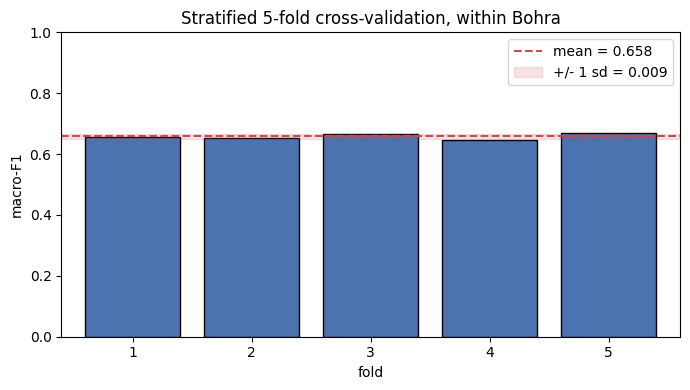

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(per_fold['fold'], per_fold['macro_f1'], color='#4c72b0', edgecolor='black')
m, s = summary['macro_f1']['mean'], summary['macro_f1']['std']
ax.axhline(m, color='#c44e52', ls='--', label=f'mean = {m:.3f}')
ax.fill_between([0.4, len(per_fold)+0.6], m-s, m+s, color='#c44e52', alpha=0.15,
                label=f'+/- 1 sd = {s:.3f}')
ax.set_xlabel('fold'); ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1)
ax.set_xticks(per_fold['fold']); ax.set_xlim(0.4, len(per_fold)+0.6)
ax.set_title('Stratified 5-fold cross-validation, within Bohra'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'cv_fold_scores.png', dpi=150, bbox_inches='tight')
print('saved', FIG_DIR/'cv_fold_scores.png'); plt.show()

## 4. Ablation under the same protocol

Word-only TF-IDF (the original baseline) versus the full feature set, both cross-validated. Same
folds, same seed, so the comparison is like-for-like.

In [9]:
rows=[]
for name, factory in [
    ('word-only TF-IDF', lambda: build_pipeline()),
    ('word+char+lexicon', lambda: build_full_pipeline(terms, clf='logreg', class_weight='balanced')),
]:
    pf, sm = stratified_kfold_evaluate(factory, X, y, n_splits=5, random_state=42, verbose=False)
    rows.append({'features':name,
                 'macro_f1_mean':round(sm['macro_f1']['mean'],3),
                 'macro_f1_std':round(sm['macro_f1']['std'],3),
                 'accuracy':round(sm['accuracy']['mean'],3),
                 'precision':round(sm['precision_macro']['mean'],3),
                 'recall':round(sm['recall_macro']['mean'],3)})
ablation = pd.DataFrame(rows)
display(ablation)

,features,macro_f1_mean,macro_f1_std,accuracy,precision,recall
0,word-only TF-IDF,0.622,0.010,0.644,0.621,0.626
1,word+char+lexicon,0.658,0.009,0.682,0.657,0.659


## 5. Save results for the write-up

In [10]:
W = FIG_DIR.parent
per_fold.to_csv(W/'cv_per_fold.csv', index=False)
pd.DataFrame([{'metric':k, 'mean':v['mean'], 'std':v['std']}
              for k,v in summary.items() if isinstance(v, dict)]).to_csv(W/'cv_summary.csv', index=False)
ablation.to_csv(W/'cv_ablation.csv', index=False)
print('saved cv_per_fold.csv, cv_summary.csv, cv_ablation.csv to writing/')
print()
print(f"HEADLINE: within-Bohra macro-F1 = {summary['macro_f1']['mean']:.3f} "
      f"+/- {summary['macro_f1']['std']:.3f} (stratified 5-fold)")

saved cv_per_fold.csv, cv_summary.csv, cv_ablation.csv to writing/

HEADLINE: within-Bohra macro-F1 = 0.658 +/- 0.009 (stratified 5-fold)


## 6. Method paragraph for the dissertation

*Draft. Adjust the numbers once you have run the cells above, and adapt the wording to your own
voice before submitting.*

---

**Evaluation protocol.** Within-dataset performance was estimated using stratified k-fold
cross-validation with N = 5 folds. A single hold-out split yields a single performance estimate
that may reflect an unrepresentative partition of the data, so k-fold was preferred in order to
quantify the variability of the estimate as well as its central value. The data were shuffled
prior to partitioning (random seed 42, fixed for reproducibility) to remove any residual ordering
in the source files, which might otherwise concentrate one class or one corpus within a single
fold. Stratified rather than uniform partitioning was used because the class distribution is
imbalanced; stratification preserves the ratio of hateful to non-hateful instances within each
fold, so every fold remains representative of the corpus as a whole. In each of the five trials,
four folds ((N-1)/N, 80 per cent of the data) were used for training and the remaining fold (1/N,
20 per cent) for testing, with the held-out fold rotating so that every instance was used for
testing exactly once. A fresh model was fitted in each trial to prevent information leaking
between folds. Accuracy, macro-averaged precision, macro-averaged recall and macro-averaged F1
were computed on each trial, and are reported below as the mean across folds with the
corresponding standard deviation. Macro-averaging was used throughout so that the minority
(hateful) class contributes equally to the reported figure.

It should be noted that this cross-validation procedure is distinct from the cross-dataset
evaluation reported in Section [X]. Cross-validation partitions a single corpus in order to
obtain a reliable estimate of within-dataset performance, whereas the cross-dataset experiment
trains on one corpus and evaluates on a different one in order to measure generalisation to an
independent source. The two are reported separately and are not combined.

**Results.** Under this protocol the statistical baseline achieved a macro-F1 of [MEAN] +/- [STD]
on the romanised Bohra corpus. The narrow spread across folds indicates that the estimate is
stable and not an artefact of a particular partition.

---

### Notes
- Quote the **mean +/- std** as the within-dataset headline from now on, replacing the single-split
  figure.
- Keep the single-split confusion matrix from notebook 06 as the illustrative error breakdown; it
  is easier to read than five separate matrices.
- Every later model (XLM-R, IndicBERT, MuRIL, LoRA LLM) should be evaluated with this same
  function and the same `random_state`, so the folds are identical and comparisons are fair.
- The cross-dataset numbers in notebook 02 stay exactly as they are.